# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse étudiant

- Bruit du secteur
- Bruit haute fréquence
- Artéfacts

## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse étudiant

- Connaissance du signal : les composantes (dérive, alpha, beta, secteur, bruit) sont connues, donc on sait exactement ce qu’il faut conserver/atténuer.
- Validation et débogage : permet de vérifier que l’implémentation du filtre fonctionne (pas d’erreur de normalisation, de signe, etc.) sans ambiguïté.
- Réglage des paramètres : on peut ajuster lowcut, highcut, order, Q et mesurer précisément leur effet (PSD, atténuation, fuites).
- Évaluation performance : comparer avant/après en temps et fréquence (PSD) pour s’assurer que les composantes utiles restent et que les artéfacts sont réduits.
- Répétabilité et tests : fournit des cas de test reproductibles pour automatiser la validation avant d’appliquer la chaîne au EEG réel.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

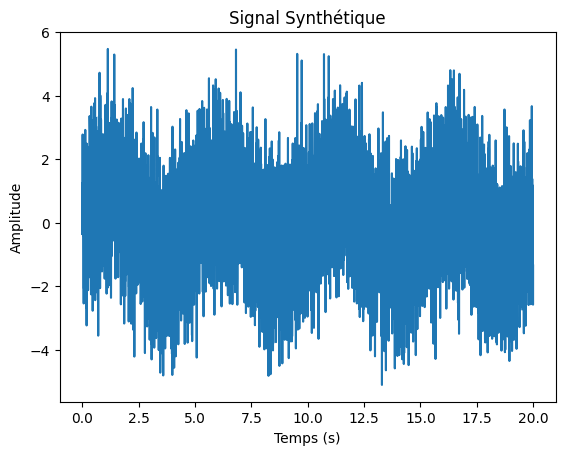

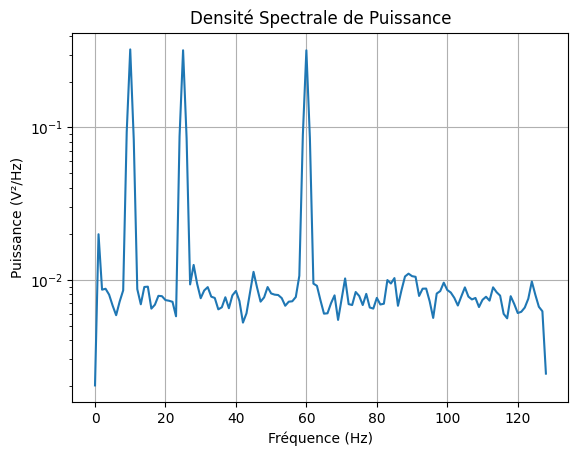

Nous observons sur la densité specetrale de puissance du signal synthétique, des pics aux mêmes fréquences des signaux qui le compose.
Nous pouvons donc désormais déduire les fréquences de n'importe quels signaux du patient pour déduire ses caractèristiques.


In [4]:
# Activité 1 — Implémenter ici la génération du signal synthétique.
# Suivre les étapes décrites dans la cellule précédente.

import matplotlib.pyplot as plt
import numpy as np
import scipy as scp

fs = 256
t = np.arange(0,20, 1/fs, dtype=np.float32)
sin_lente = np.sin(2*np.pi*0.2*t) # f=0.2Hz
sin_alpha = np.sin(2*np.pi*10*t) # f=10Hz 
sin_beta = np.sin(2*np.pi*25*t) # f=25Hz
sin_secteur = np.sin(2*np.pi*60*t) # f=60Hz 
bruit = np.random.normal(loc=0.0, scale=1.0, size=5120)

signal_synthetique = sin_lente + sin_alpha + sin_beta + sin_secteur + bruit

f, Pxx = scp.signal.welch(signal_synthetique, fs)

plt.figure()
plt.plot(t,signal_synthetique)
plt.title("Signal Synthétique")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.semilogy(f, Pxx)
plt.title("Densité Spectrale de Puissance")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (V²/Hz)")
plt.grid(True)
plt.show()
print("Nous observons sur la densité specetrale de puissance du signal synthétique, des pics aux mêmes fréquences des signaux qui le compose.\nNous pouvons donc désormais déduire les fréquences de n'importe quels signaux du patient pour déduire ses caractèristiques.")


## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conserve les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse étudiant

On utilise filtfilt ou sosfiltfilt en analyse hors ligne parce que ces fonctions filtrent le signal dans les deux sens. Cela annule le déphasage introduit par un filtrage causal classique, donc les pics et les variations restent alignés dans le temps.

C’est important pour l’EEG, car on veut modifier le contenu fréquentiel sans déplacer artificiellement les événements. sosfiltfilt est en plus plus stable numériquement quand le filtre est écrit en sections de second ordre.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse étudiant

Fn = fs/2 = 256/2 = 128 Hz

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

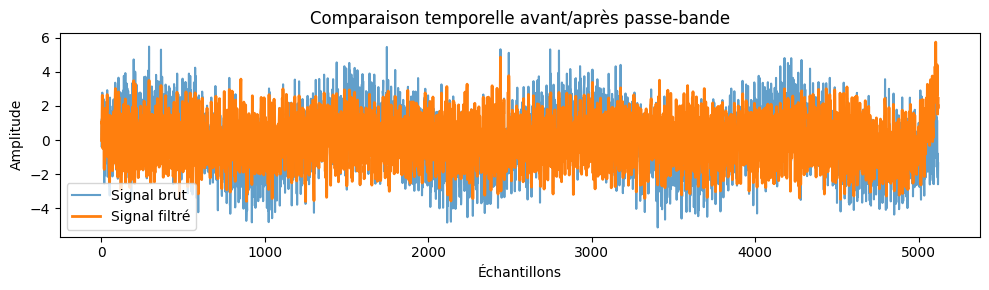

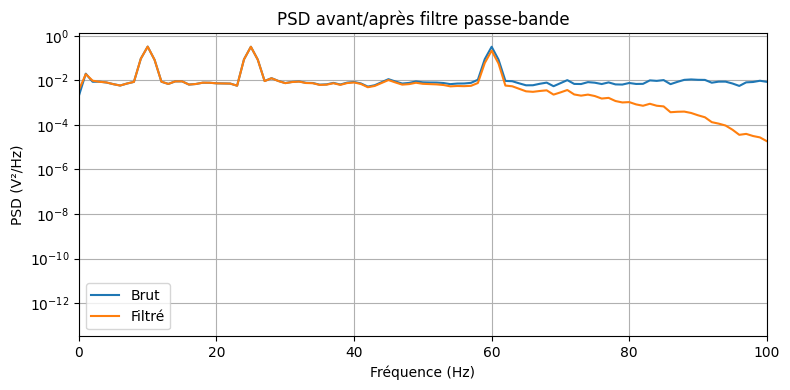

Le filtre passe-bande conserve principalement les composantes comprises entre 0.4 et 75 Hz.
La dérive très lente est atténuée, tandis que les composantes utiles restent.


In [9]:
# Activité 2 — Implémenter ici le filtre passe-bande.
from scipy.signal import butter, sosfiltfilt, welch

fs = 256
lowcut = 0.4
highcut = 75
order = 2
fn = fs / 2.0
Wlow = lowcut / fn
Whigh = highcut / fn

bandpass_filter = butter(order, [Wlow, Whigh], btype='bandpass', output='sos')
signal_filtre = sosfiltfilt(bandpass_filter, signal_synthetique)

f_brut, pxx_brut = welch(signal_synthetique, fs=256)
f_filtre, pxx_filtre = welch(signal_filtre, fs=256)

plt.figure(figsize=(10, 3))
plt.plot(signal_synthetique, label="Signal brut", alpha=0.7)
plt.plot(signal_filtre, label="Signal filtré", linewidth=2)
plt.title("Comparaison temporelle avant/après passe-bande")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogy(f_brut, pxx_brut, label="Brut")
plt.semilogy(f_filtre, pxx_filtre, label="Filtré")
plt.xlim(0, 100)
plt.title("PSD avant/après filtre passe-bande")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Le filtre passe-bande conserve principalement les composantes comprises entre 0.4 et 75 Hz.")
print("La dérive très lente est atténuée, tandis que les composantes utiles restent.")


## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse étudiant

À rédiger ici.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse étudiant

À rédiger ici.

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

In [ ]:
# Activité 3 — Implémenter ici le filtre notch.

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

In [ ]:
# Activité 4 — Implémenter ici une fonction preprocess_eeg_1d.
# Elle doit gérer les NaN courts, appliquer le passe-bande, puis le notch.

### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse étudiant

À rédiger ici.

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse étudiant

À rédiger ici.

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse étudiant

À rédiger ici.

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse étudiant

À rédiger ici.

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

In [ ]:
# Activité 5 — Implémenter ici une fonction preprocess_eeg_dataframe.

## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

In [ ]:
# Activité 6 — Charger ici un fichier EEG du dataset CL-Drive.

### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

In [ ]:
# Activité 7 — Visualiser ici les signaux EEG avant/après et leurs PSD.

### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse étudiant

À rédiger ici.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse étudiant

À rédiger ici.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse étudiant

À rédiger ici.

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.

In [ ]:
# Activité 8 — Implémenter un rapport qualité simple pour les canaux EEG.

## 9. Prétraitement par lot

Dans le projet final, on appliquera la même fonction à plusieurs fichiers EEG.

Algorithme :

1. définir le dossier EEG ;
2. parcourir les fichiers CSV ;
3. ignorer les fichiers déjà filtrés ;
4. charger chaque fichier ;
5. appliquer `preprocess_eeg_dataframe` ;
6. sauvegarder une copie `filtered_...csv` ;
7. produire un diagnostic.

Pour info, la structure de l'ensemble de données est la suivante :

```text
CL-Drive
    |----EEG 
         |----participant_ID_1
                      |----eeg_data_level_1
                      |----eeg_baseline_level_1
                      .
                      .
                      .
                      |----eeg_data_level_9
                      |----eeg_baseline_level_9
         .
         .
         .
         |----participant_ID_21
    |----EDA
    |----ECG
    |----Gaze
    |----Labels
```

In [ ]:
# Activité 9 — Implémenter une fonction de prétraitement par lot.
# Exemple à adapter :
# saved_files = run_batch_eeg_preprocessing(DATASET_ROOT /EEG, fs=256, notch_freq=60)